#### Carnegie Mellon University - Tepper School of Business
#### 46-881 - Programming in R and Python
#### 22/23 - Mini 2 - Sections MO2 - Farahat
---

## Deliverable 2 
**Due November 16th at 2:59 a.m. Eastern**

Please provide your name and Andrew ID below:

- Name (Last, First): Hrishikesh Mysore Harishkumar

- Andrew ID: hmysoreh@andrew.cmu.edu

---

*This deliverable consists of **two** Problems. Both problems require you to code in Python and answer one or more questions. Save a copy of this notebook and provide your solution by inserting code or Markdown text files as appropriate.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook.*

### Problem 1 (60 points)

The SIR model is the original and simplest (in fact, *simplistic*) model of disease spread in epidemiology. It is a *compartmental model* where each individual in a population is classified as being in exactly one of 3 states at any gien time: **S**usceptible to infection, **I**nfectious (i.e. infected and capable of infecting susceptible individuals), or **R**ecovered (or "removed"). The model was developed by Kermack and McKendrick in 1927. Many improved predictive models have since been developed for disease spread. In this problem you will use Python to implement and explore this model.

Let S(t), I(t), and R(t) denote, respectively, the number of individuals in a given population who are susceptible, infectious, and recovered on day t. The model utilizes two parameters: Beta and Gamma. For a population of size N, the time-dynamics of the model are as follows:
- S(t+1) = S(t) - Beta * I(t) * S(t) / N
- I(t+1) = I(t) + Beta * I(t) * S(t) / N - Gamma * I(t)
- R(t+1) = R(t) + Gamma * I(t) 

The ratio Beta / Gamma is sometimes referred to as the R0 (R naught) of the disease.

Develop a Python model of the above SIR model and use it to answer the following questions. Assume a scenario where N = 1000, S(0) = 990, I(0) = 10, Beta = 0.10, and Gamma = 0.05.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
days = 365
S = np.zeros (days)
I = np.zeros (days)
R = np.zeros (days)
N = 1000
S[0] = 990
I[0] = 10
R[0] = 0
beta = 0.1
gamma = 0.05


for i in range(days - 1):
    S[i+1] = S[i] - beta * I[i] * S[i] / N
    I[i+1] = I[i] + beta * I[i] * S[i] / N - gamma * I[i]
    R[i+1] = R[i] + gamma * I[i]


Text(0, 0.5, 'Population')

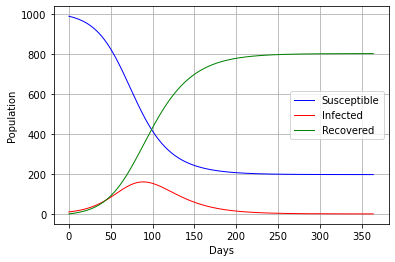

In [3]:
plt.grid()
plt.plot(S, 'b',lw=1, label='Susceptible')
plt.plot(I, 'r',lw=1, label='Infected')
plt.plot(R, 'g',lw=1, label='Recovered')

plt.legend()
plt.xlabel('Days');plt.ylabel('Population')

#### Part(a)
Suppose our healthcare system has a capacity to accommodate a maximum of 120 infectious persons. Is this capacity sufficient according to the model?

In [4]:
max(I)

160.37770863476757

## Answer:

#### *According to the model, the maximum number of people that can get infected is 160. So, the healthcare system capacity isn't sufficient.*

#### Part (b)
Now suppose that our healthcare system can currently accommodate only 120 infectious persons. However, its capacity can be increased to accommodate 180 infectious persons in 2 months. Is this current capacity and expansion plan sufficient according to the model?

In [5]:
np.where(I == max(I))

(array([89]),)

## Answer:

#### *As per the Model, the number of infected individuals will reach its peak (160) in around 90 days (~ 3 months). So the expansion plan to accommodate 180 infectious persons in 2 months is indeed sufficient.*

----

### Problem 2 (40 points)

Suppose you drive a car whose fuel efficiency is 18 miles per gallon and whose gas tank size is 16 gallons. Gas prices fluctuate according to a **uniform distribution** ranging from 3 dollars per gallon to 5 dollars per gallon. That is, prices remain average equal to 4 dollars per gallon but fluctuate each day according to this uniform distribution. Every day you drive your car for exactly 10 miles.

You are contemplating two gas filling strategies:
- *“Fill-it up” strategy*: You wait till the tank is (almost) empty then fill the entire tank;
- *“30-dollar” strategy*: You wait till the tank is (almost) empty then fill in only 30 dollars worth of gas.

Assume that there are many gas stations around, so you can time your visits almost exactly when the tank is empty. Assume also that any inconvenience from visiting the gas station is negligible. Your only objective is to minimize your gas expenditure.

***Construct a simulation model in Python to determine if one strategy is more economical than the other (and, if so, by how much).*** 

In [6]:
#Given parameters

fuel_eff = 18
tank_size = 16
distance_per_day = 10
gp_lower_bound = 3
gp_upper_bound = 5

In [7]:
#Strategy 1: "Fill-it up” strategy

tot_num_days = 10000 ##Fixing the total number of days
tot_miles = tot_num_days * distance_per_day
refill_count = int(tot_miles /(fuel_eff * tank_size))
strategy1_tot_cost =[]
for i in range(refill_count - 1):
    rng = np.random.default_rng(seed=881)
    gas_price = rng.uniform(gp_lower_bound, gp_upper_bound)
    full_tank_cost = 16 * gas_price
    strategy1_tot_cost.append(full_tank_cost)

strategy1_tot_exp = sum(strategy1_tot_cost)

print("At the end of 10000th day, the total $ spend on gas with the 'Fill it up strategy' is:", "$",int(strategy1_tot_exp))


At the end of 10000th day, the total $ spend on gas with the 'Fill it up strategy' is: $ 19587


In [8]:
#Strategy 2: "30-dollar” strategy"

count = 0
cumulative_miles_driven = 0
while cumulative_miles_driven < tot_miles:
    rng = np.random.default_rng(seed=881)
    gas_price = rng.uniform(gp_lower_bound, gp_upper_bound)
    no_of_gallons_per_fill = 30/gas_price
    tot_miles_driven_each_fill = 18 * no_of_gallons_per_fill

    cumulative_miles_driven += tot_miles_driven_each_fill    
    count +=1
    
strategy2_tot_exp = count * 30

print("At the end of 10000th day, the total $ spend on gas with the '30 dollar strategy' is:","$", int(strategy2_tot_exp))


At the end of 10000th day, the total $ spend on gas with the '30 dollar strategy' is: $ 19680


## Conclusion

#### *Per the logic above, in the long run, we do not see big difference between the two strategies in terms of the total gas expenditure.So, we're okay to go with either of the strategies.*